# Land Use Classification from Satellite Images  

Group 4: Teresa Alvarez, Vikram Bhatt, Alessandro Cristofolini, Matteo Khoueiri, Dominique Robson, & Pengchong Zhao

---

## Executive Summary

In this project, we address the problem of land use classification using satellite image patches from the EuroSAT RGB dataset. The objective is to automatically classify land cover types (e.g., Forest, Residential, River, Industrial) from aerial imagery.

We compare two approaches:

1. A classical computer vision baseline using HOG features and a linear SVM.
2. A deep learning approach using transfer learning with a pretrained Convolutional Neural Network (CNN).


----
# 1. Business / Research Question

## Problem

Can satellite image patches be automatically classified into land use categories to support environmental monitoring and urban planning?

## Motivation

Manual annotation of satellite imagery is costly and time-consuming. Automated classification can:

- Accelerate large-scale analysis
- Support planning and monitoring
- Flag uncertain cases for human review

The system is intended as decision support rather than full automation.

In [1]:
from pathlib import Path
import random
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# 2. Dataset

## 2.1 Source

We use the EuroSAT RGB dataset:

- ~27,000 satellite image patches
- 10 land use classes
- RGB format, 64×64 resolution
- Images organized in class-based folders

## 2.2 Classes

- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake

Each image represents a satellite patch labeled with its dominant land use type.

In [2]:
DATA_DIR = Path("img")

# Verificar que existe
if not DATA_DIR.exists():
    raise FileNotFoundError(f"{DATA_DIR} not found")

# Detectar clases (subcarpetas)
classes = sorted([folder.name for folder in DATA_DIR.iterdir() if folder.is_dir()])

print(f"Number of classes detected: {len(classes)}")
print("Classes:")
for c in classes:
    print("-", c)

Number of classes detected: 10
Classes:
- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake


In [3]:
image_extensions = {".jpg", ".jpeg", ".png"}

data = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    data.append({
        "class": cls,
        "num_images": len(images)
    })

df_counts = pd.DataFrame(data).sort_values("class")
total_images = df_counts["num_images"].sum()

print(df_counts)
print("\nTotal images:", total_images)

                  class  num_images
0            AnnualCrop        3000
1                Forest        3000
2  HerbaceousVegetation        3000
3               Highway        2500
4            Industrial        2500
5               Pasture        2000
6         PermanentCrop        2500
7           Residential        3000
8                 River        2500
9               SeaLake        3000

Total images: 27000


## 2.3 Visualization of classes

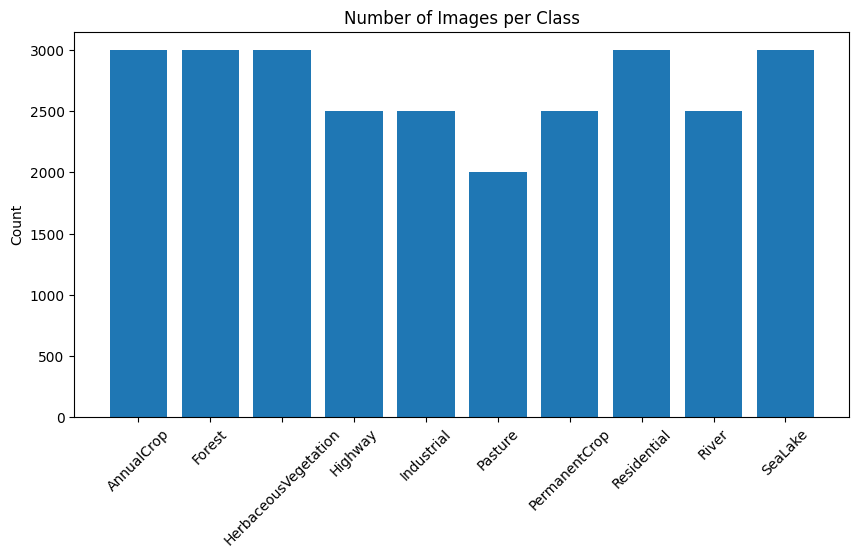

In [4]:
plt.figure(figsize=(10,5))
plt.bar(df_counts["class"], df_counts["num_images"])
plt.xticks(rotation=45)
plt.title("Number of Images per Class")
plt.ylabel("Count")
plt.show()

## 2.4 Corrupted image check

No images are corrupter out of the 27000

In [5]:
corrupted = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    sample_images = random.sample(images, min(200, len(images)))
    
    for img_path in sample_images:
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupted.append(img_path)

print("Number of corrupted images found:", len(corrupted))

Number of corrupted images found: 0


## Showing sample images

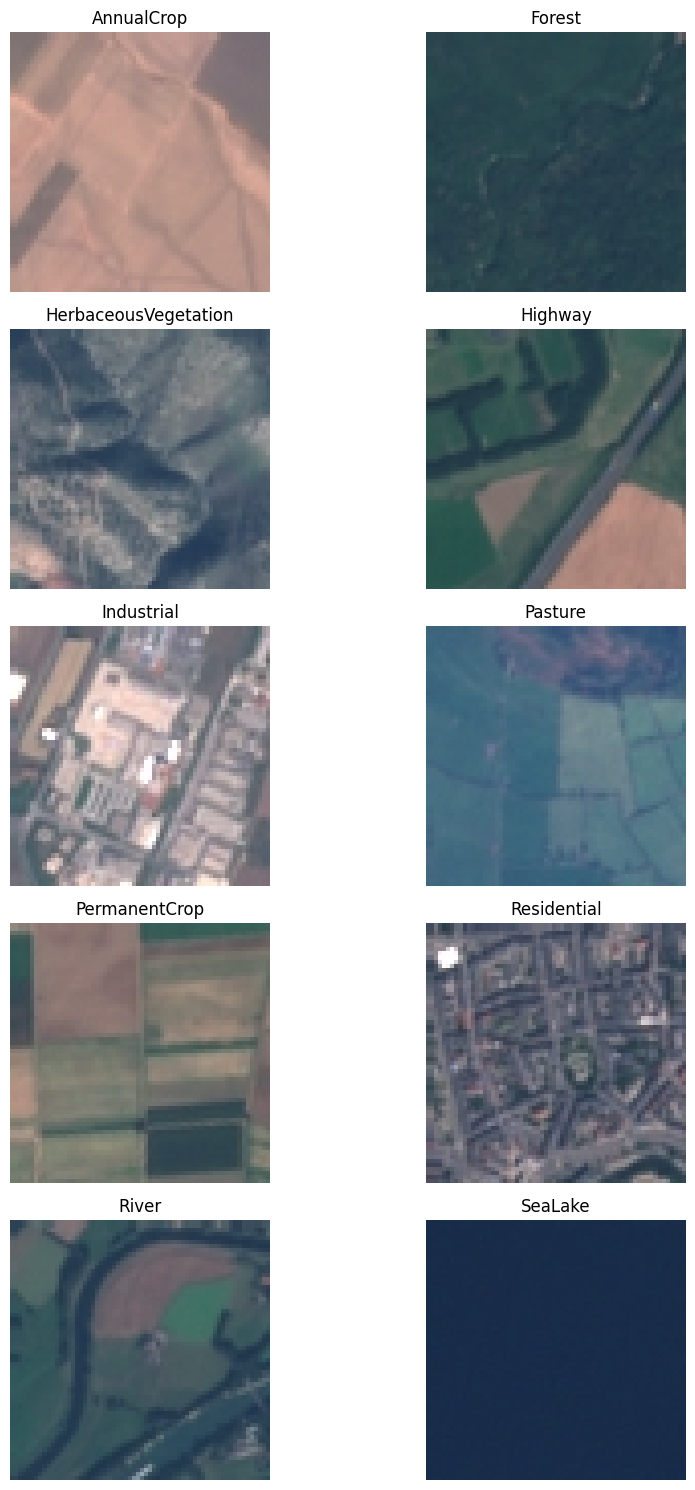

In [6]:
fig, axes = plt.subplots(5, 2, figsize=(10,15))

df_all = pd.read_csv("csv/image_data.csv")  

for ax, cls in zip(axes.flat, classes):
    sample_path = df_all[df_all["label"] == cls]["path"].sample(1).values[0]
    img = plt.imread(sample_path)
    
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2.5 Dataset Indexing

To prepare the dataset for model training, we construct a master DataFrame containing:

- The image file path
- The corresponding class label

This structured representation will allow us to perform a reproducible train/validation/test split while ensuring consistency across models.

In [7]:
all_data = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    for img_path in images:
        all_data.append({
            "path": str(img_path),
            "label": cls
        })

df_all = pd.DataFrame(all_data)

print("Total images indexed:", len(df_all))
df_all.head()

#guardar dataframe por si acaso
df_all.to_csv("csv/image_data.csv", index=False)

Total images indexed: 27000


In [8]:
df_all["label"].value_counts()

label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
SeaLake                 3000
Highway                 2500
Industrial              2500
PermanentCrop           2500
River                   2500
Pasture                 2000
Name: count, dtype: int64

# 3. Experimental Setup

## 3.1 Train / Validation / Test Split

The dataset is split into:

- 70% Training
- 15% Validation
- 15% Test

The split is stratified by class to preserve class balance.

A fixed random seed ensures reproducibility.

In [9]:
#Codificar etiquetas a números
label_encoder = LabelEncoder()

df_all["label_encoded"] = label_encoder.fit_transform(df_all["label"])

num_classes = len(label_encoder.classes_)

print("Number of classes:", num_classes)
print("Class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Number of classes: 10
Class mapping:
0 -> AnnualCrop
1 -> Forest
2 -> HerbaceousVegetation
3 -> Highway
4 -> Industrial
5 -> Pasture
6 -> PermanentCrop
7 -> Residential
8 -> River
9 -> SeaLake


In [10]:
SEED = 42

#train vs temp (30% para temp)
train_df, temp_df = train_test_split(
    df_all,
    test_size=0.30,
    stratify=df_all["label_encoded"],
    random_state=SEED
)

# Dividir temp en validation (15%) y test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_encoded"],
    random_state=SEED
)

#verify size of splits
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 18900
Validation size: 4050
Test size: 4050


In [11]:
print("Train distribution:\n", train_df["label"].value_counts(normalize=True))
print("\nValidation distribution:\n", val_df["label"].value_counts(normalize=True))
print("\nTest distribution:\n", test_df["label"].value_counts(normalize=True))

Train distribution:
 label
Residential             0.111111
SeaLake                 0.111111
AnnualCrop              0.111111
Forest                  0.111111
HerbaceousVegetation    0.111111
PermanentCrop           0.092593
Industrial              0.092593
Highway                 0.092593
River                   0.092593
Pasture                 0.074074
Name: proportion, dtype: float64

Validation distribution:
 label
SeaLake                 0.111111
HerbaceousVegetation    0.111111
Forest                  0.111111
AnnualCrop              0.111111
Residential             0.111111
Highway                 0.092593
Industrial              0.092593
PermanentCrop           0.092593
River                   0.092593
Pasture                 0.074074
Name: proportion, dtype: float64

Test distribution:
 label
SeaLake                 0.111111
AnnualCrop              0.111111
Residential             0.111111
Forest                  0.111111
HerbaceousVegetation    0.111111
PermanentCrop         

In [12]:
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

df_splits = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

df_splits.head(),df_splits["split"].value_counts()

(                                   path        label  label_encoded  split
 0   img\Residential\Residential_238.jpg  Residential              7  train
 1          img\SeaLake\SeaLake_1784.jpg      SeaLake              9  train
 2  img\Residential\Residential_2621.jpg  Residential              7  train
 3     img\AnnualCrop\AnnualCrop_361.jpg   AnnualCrop              0  train
 4            img\Forest\Forest_1198.jpg       Forest              1  train,
 split
 train    18900
 val       4050
 test      4050
 Name: count, dtype: int64)

In [13]:
train_df.to_csv("csv/train_data.csv", index=False)
val_df.to_csv("csv/val_data.csv", index=False) 
test_df.to_csv("csv/test_data.csv", index=False)

df_splits.to_csv("csv/splits_data.csv", index=False)

## 3.2 Metrics functions

### Confusion matrix

In [14]:
def plot_confusion_matrix(y_true, y_pred, class_names, normalize=False):
    """
    Plots confusion matrix.
    
    Parameters:
    - y_true: true labels
    - y_pred: predicted labels
    - class_names: list of class names
    - normalize: if True, show percentages instead of raw counts
    """
    
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Model evaluations

In [15]:
def evaluate_model(y_true, y_pred, class_names, model_name="Model"):
    """
    Computes and prints evaluation metrics.
    Returns dictionary with results.
    """
    
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    
    print(f"\n===== {model_name} Evaluation =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {f1_macro:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion matrices
    plot_confusion_matrix(y_true, y_pred, class_names, normalize=False)
    plot_confusion_matrix(y_true, y_pred, class_names, normalize=True)
    
    return {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": f1_macro
    }

### Comparative table

In [16]:
def compare_models(results_list):
    """
    Creates comparison table from evaluation results.
    
    results_list: list of dictionaries returned by evaluate_model()
    """
    
    results_df = pd.DataFrame(results_list)
    results_df = results_df.set_index("model")
    
    print("\n===== Model Comparison =====")
    display(results_df)
    
    return results_df

# 5. Main Model: CNN

In [17]:
#instalar paquetes necesarios para entrenamiento. hacer pip install
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm.notebook import tqdm

## 5.1 Charging and verification of data

We define two preprocessing pipelines:

- Training: resize + random horizontal flip + normalization
- Validation/Test: resize + normalization only

This ensures augmentation is applied only to training data.

In [18]:
# Rutas a tus CSV (ajusta si tus archivos están en otra carpeta)
train_csv = "csv/train_data.csv"
val_csv   = "csv/val_data.csv"
test_csv  = "csv/test_data.csv"

train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("Shapes:")
print("train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)


Shapes:
train: (18900, 4) val: (4050, 4) test: (4050, 4)


## 5.2: Paths y labels extraction

In [19]:
# #2 Extracción de paths y labels

# Convertimos a arrays (esto es lo que alimentará tf.data.Dataset)
train_paths  = train_df["path"].astype(str).to_numpy()
train_labels = train_df["label_encoded"].astype(int).to_numpy()

val_paths  = val_df["path"].astype(str).to_numpy()
val_labels = val_df["label_encoded"].astype(int).to_numpy()

test_paths  = test_df["path"].astype(str).to_numpy()
test_labels = test_df["label_encoded"].astype(int).to_numpy()

print("train_paths:", train_paths.shape, "train_labels:", train_labels.shape)
print("val_paths:  ", val_paths.shape,   "val_labels:  ", val_labels.shape)
print("test_paths: ", test_paths.shape,  "test_labels: ", test_labels.shape)

# Sanity check rápido (primeros 3)
for i in range(3):
    print("\nEjemplo", i)
    print("  path :", train_paths[i])
    print("  label:", train_labels[i])

train_paths: (18900,) train_labels: (18900,)
val_paths:   (4050,) val_labels:   (4050,)
test_paths:  (4050,) test_labels:  (4050,)

Ejemplo 0
  path : img\Residential\Residential_238.jpg
  label: 7

Ejemplo 1
  path : img\SeaLake\SeaLake_1784.jpg
  label: 9

Ejemplo 2
  path : img\Residential\Residential_2621.jpg
  label: 7


## 5.3. Pipeline

pq tensorflow?

debido a la robustez, facilidad de uso con keras y alto rendimiento en producción

In [20]:
import tensorflow as tf

IMG_SIZE = 64
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [21]:
# #3.1 Función de lectura y preprocesado

def preprocess_image(path, label):
    # Leer imagen
    image = tf.io.read_file(path)
    
    # Decodificar (forzamos 3 canales RGB)
    image = tf.image.decode_jpeg(image, channels=3)
    
    # Redimensionar a 224x224
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    
    # Normalizar a rango [0,1]
    image = image / 255.0
    
    return image, label

# #3.2 Crear Dataset base

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds   = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_ds  = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

In [22]:
# #3.3 Aplicar map (preprocesado)

train_ds = train_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
test_ds  = test_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)

In [23]:
# #3.4 Shuffle solo en entrenamiento

train_ds = train_ds.shuffle(buffer_size=len(train_paths))

In [24]:
# #3.5 Batching

train_ds = train_ds.batch(BATCH_SIZE)
val_ds   = val_ds.batch(BATCH_SIZE)
test_ds  = test_ds.batch(BATCH_SIZE)

" pq 32 de batch size? "


In [25]:
# #3.6 Prefetch

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

In [26]:
for images, labels in train_ds.take(1):
    print("Shape imágenes:", images.shape)   # (32, 224, 224, 3)
    print("Shape labels:", labels.shape)     # (32,)
    print("Min pixel:", tf.reduce_min(images).numpy())
    print("Max pixel:", tf.reduce_max(images).numpy())
    

Shape imágenes: (32, 64, 64, 3)
Shape labels: (32,)
Min pixel: 0.09019608
Max pixel: 1.0


## 5.4 Arquitecture

In [44]:
from tensorflow.keras import layers, models

num_classes = 10

model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291,498 (1.11 MB)

 Trainable params: 291,498 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# #5.1 Entrenamiento

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.5078 - loss: 1.3193 - val_accuracy: 0.6220 - val_loss: 1.0437
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.6944 - loss: 0.8516 - val_accuracy: 0.7491 - val_loss: 0.6974
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.7701 - loss: 0.6392 - val_accuracy: 0.7881 - val_loss: 0.5794
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 35s 49ms/step - accuracy: 0.8065 - loss: 0.5460 - val_accuracy: 0.7696 - val_loss: 0.6539
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.8228 - loss: 0.4999 - val_accuracy: 0.7958 - val_loss: 0.5627
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.8390 - loss: 0.4520 - val_accuracy: 0.8286 - val_loss: 0.4789
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.8585 - loss: 0.3993 - val_accuracy: 0.8104 - val_loss: 0.5589
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.8751 - loss: 0.3550 - 

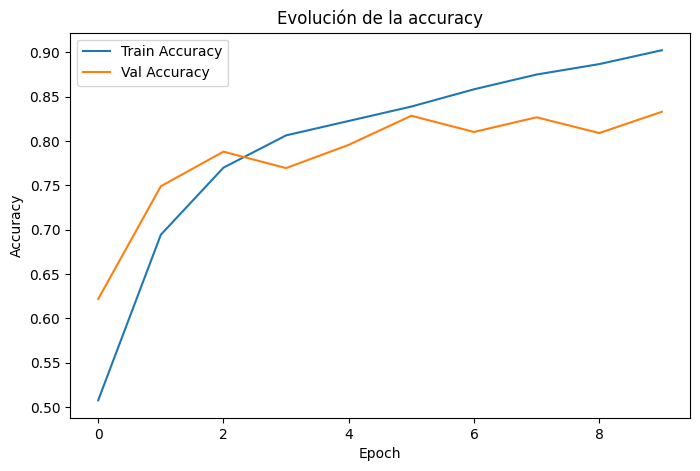

In [46]:
# #5.2 Curvas de entrenamiento

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Evolución de la accuracy')
plt.legend()
plt.show()

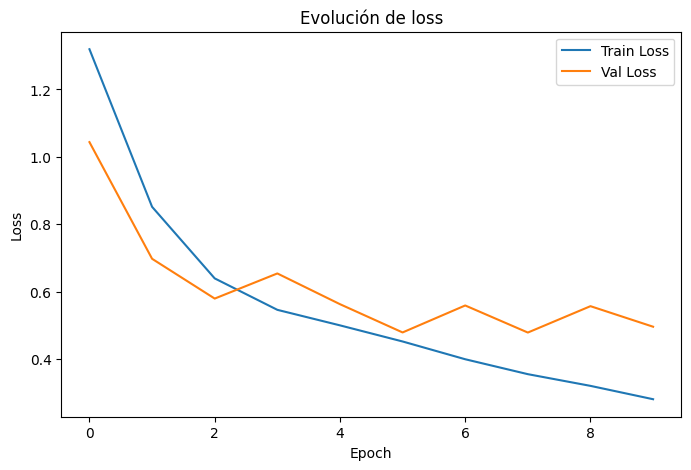

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolución de loss')
plt.legend()
plt.show()

During the first epochs both training and validation loss decrease, indicating that the model is learning useful patterns from the data. However, after approximately epoch 5 the validation loss stops improving while the training loss continues to decrease. This suggests that the model starts overfitting the training data. The best model therefore corresponds to the epoch with the lowest validation loss.

In [48]:
# #6.1 Evaluación en test

test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8435 - loss: 0.4597
Test Loss: 0.4597
Test Accuracy: 0.8435


In [49]:
# #6.2 Predicciones sobre test

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Shape probabilidades:", y_pred_probs.shape)
print("Shape predicciones:", y_pred.shape)
print("Primeras 10 predicciones:", y_pred[:10])

127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
Shape probabilidades: (4050, 10)
Shape predicciones: (4050,)
Primeras 10 predicciones: [6 9 0 4 8 3 0 9 8 7]


In [50]:
# #6.3 Labels reales

y_true = np.concatenate([labels.numpy() for images, labels in test_ds])

print("Shape labels reales:", y_true.shape)
print("Primeros 10 labels reales:", y_true[:10])

Shape labels reales: (4050,)
Primeros 10 labels reales: [6 9 0 4 3 3 0 9 8 7]


In [51]:
# Obtener nombres de clase
class_names = (
    pd.concat([train_df, val_df, test_df])[["label_encoded", "label"]]
    .drop_duplicates()
    .sort_values("label_encoded")["label"]
    .tolist()
)

print(class_names)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


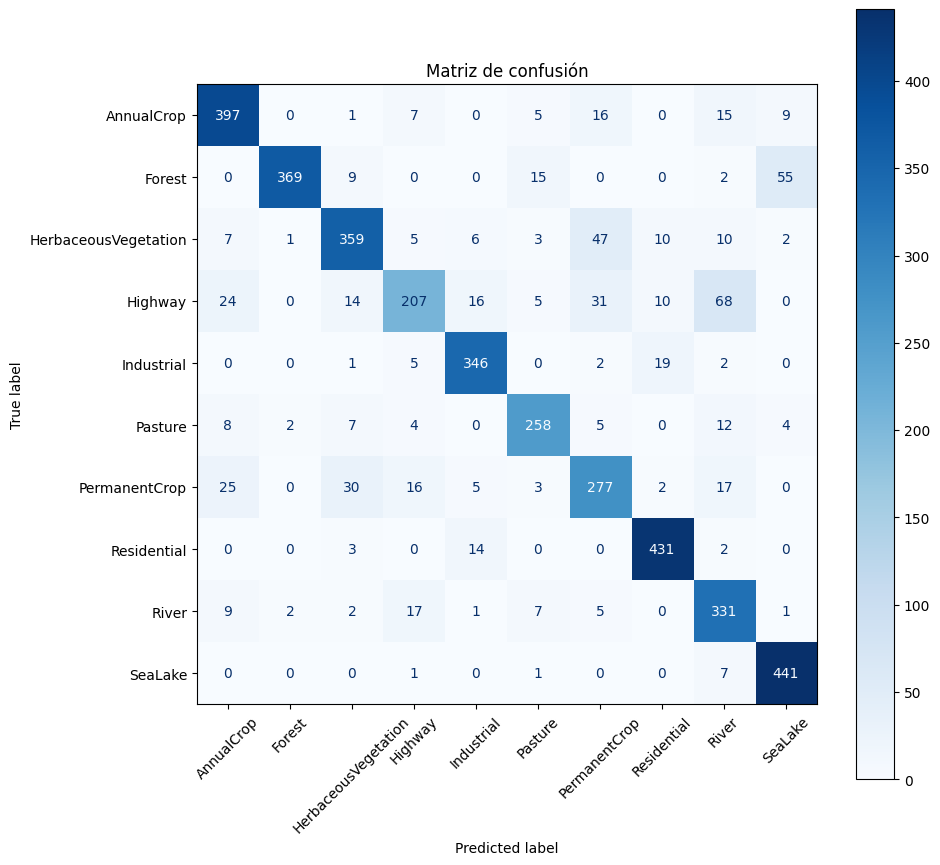

In [52]:
# 7.1 Matriz de confusión con nombres de clase

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=45)
plt.title("Matriz de confusión")
plt.show()

In [53]:
# #7.2 Classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       450
           1       0.99      0.82      0.90       450
           2       0.84      0.80      0.82       450
           3       0.79      0.55      0.65       375
           4       0.89      0.92      0.91       375
           5       0.87      0.86      0.86       300
           6       0.72      0.74      0.73       375
           7       0.91      0.96      0.93       450
           8       0.71      0.88      0.79       375
           9       0.86      0.98      0.92       450

    accuracy                           0.84      4050
   macro avg       0.84      0.84      0.84      4050
weighted avg       0.85      0.84      0.84      4050



In [54]:
# #7.3 Accuracy global

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print(f"Accuracy global: {acc:.4f}")

Accuracy global: 0.8435
